This version is going to look at training on a given time series then looking at the likelihood of the testing series being possible given the train series. 

Chose the training set to include the 2020 COVID crash out of curiosity and to follow the methods of the paper. 

Percentage change of the data is taken as oppose to raw end of day pricing since that is genrally considered a statinary time series which allows PCA to be used. 

Train series: 2019-01-01 -> 2024-12-31

Test series: 2025-01-01 -> present

In [1]:
import yfinance as yf 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
import scipy.stats as stats

from sklearn.decomposition import PCA 
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import cross_val_score, TimeSeriesSplit 

from hmmlearn import hmm

seed = 123
random.seed(seed)

In [2]:
tickers = ["XLK","XLV","XLF","XLY","XLC","XLI","XLP","XLE","XLU","XLRE","XLB","^VIX", "^SPX"]
sector_data = yf.download(tickers, start="2019-01-01", auto_adjust = False)["Adj Close"]
returns = sector_data.pct_change().dropna()

[*********************100%***********************]  13 of 13 completed


Now split into the training and testing sets

In [3]:
cut_date = "2025-01-01"

test_data = returns[returns.index >= cut_date]
train_data = returns[returns.index < cut_date]

test_data.shape, train_data.shape


((309, 13), (1509, 13))

In [4]:
scaler = StandardScaler()

train_scaled = pd.DataFrame(
    scaler.fit_transform(train_data), 
    columns = returns.columns
)

In [5]:
test_scaled = pd.DataFrame(
    scaler.transform(test_data), 
    columns = returns.columns
    )

In [6]:
pca = PCA(n_components=3, random_state=seed)

latent_train = pca.fit_transform(train_data)

latent_test = pca.transform(test_data)

latent_test.shape, latent_train.shape

((309, 3), (1509, 3))

In [7]:
Saved_PC = ["PC1", 'PC2', "PC3"]
df_loadings = pd.DataFrame(
    pca.components_, 
    columns = returns.columns, 
    index = Saved_PC 
)
df_loadings.head()

Ticker,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY,^SPX,^VIX
PC1,-0.110093,-0.112513,-0.119422,-0.118724,-0.109772,-0.138610,-0.063051,-0.094030,-0.066895,-0.078948,-0.124906,-0.112212,0.929453
PC2,0.289180,0.208321,0.406817,0.321216,0.288295,0.229844,0.180758,0.294909,0.266637,0.189425,0.235695,0.239314,0.359041
PC3,0.042361,-0.264234,0.795227,0.115010,0.043761,-0.325032,-0.130688,-0.186727,-0.160369,-0.129163,-0.241175,-0.140988,-0.053107


In this case it looks like we're more strongly predicting the bearish case in PC1 as opposed to the last script where we were looking in the direction of the bullish

In [8]:
pca.explained_variance_ratio_

array([0.82256446, 0.09578838, 0.03077928])

### Setting up the HMM Model

Choosing two hidden states and not initializing the transition matrix or inital probabilities 

In [ ]:
hmm_model = hmm.GaussianHMM(n_components=2, random_state=seed)

#### Checking the metrics of model by doing CV on the Latent Test Data 

This would help be able to tell the stability of the loglikleihood esitmate on the training set as well as the stability of the state means and transition matrix 

We should see a trend that the log likelihood increases than converge after enough data is seen since the trend is assumed stationary. Deviaiton in that trend could be due to the unnderlying data that is used in each respective split since outliers will be harder to fit. 

1. Split data -> time series split in scikit learn 
2. Fit the model on a component of the training data -> training set of the training set 
3. Evaluate the model on the other part of the training set that was not used for the training 
4. Compute the state means, transition matrix and the normalized log lieklihood estimate 

In [62]:
tscv = TimeSeriesSplit(n_splits = 10)

In [63]:
state_means = []
trans_matrx = []
scores = []

for train_idx, val_idx in tscv.split(latent_train):
    tr = latent_train[train_idx]
    val = latent_train[val_idx]

    hmm_model.fit(tr)

    scores.append(hmm_model.score(val)/len(val))
    trans_matrx.append(hmm_model.transmat_)
    state_means.append(hmm_model.means_)


Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'
Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'
Model is not converging.  Current: 1015.2629143636317 is not greater than 1015.5800311561412. Delta is -0.3171167925095233
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'
E

In [66]:
state_means

[array([[-0.01428706, -0.0009081 , -0.00062645],
        [ 0.12543311,  0.0198541 , -0.00420089]]),
 array([[ 0.11366553,  0.01697073, -0.00387461],
        [-0.01962901, -0.00200637, -0.00081415]]),
 array([[-0.0098    ,  0.00010325, -0.00131049],
        [ 0.05269443,  0.00207012, -0.00345506]]),
 array([[ 0.05474332,  0.00369482, -0.00115861],
        [-0.00904084,  0.00065147, -0.00061865]]),
 array([[-0.00830795,  0.00040787, -0.000711  ],
        [ 0.05504444,  0.00419804, -0.00127008]]),
 array([[-7.39217596e-03,  4.17673852e-04, -3.05220561e-06],
        [ 6.14800315e-02,  4.99878818e-03, -1.35418784e-03]]),
 array([[-9.00910596e-03,  2.92309254e-05,  3.05319600e-04],
        [ 5.49882464e-02,  1.49478126e-03,  2.24884944e-04]]),
 array([[-0.00866521, -0.0004941 ,  0.00029652],
        [ 0.05347154,  0.00244379, -0.00075928]]),
 array([[-0.00828306, -0.00072042,  0.00024942],
        [ 0.05073917,  0.00284035, -0.00043814]]),
 array([[-7.79731378e-03, -6.26627264e-04,  1.008769

In [64]:
state_zero_is_bull = []
rows = []
for i, sm in enumerate(state_means): 
    if sm[0][0] < 0: 
        state_zero_is_bull.append(True)
        bull_means = sm[0] 
        
        bull_to_bear = trans_matrx[i][0][1]
        bull_to_bull = trans_matrx[i][0][0]

        bear_to_bull = trans_matrx[i][1][0]
        bear_to_bear = trans_matrx[i][1][1]

        bear_means = sm[1]
        
    else:
        state_zero_is_bull.append(False)
        bull_means = sm[1] 

        bull_to_bear = trans_matrx[i][1][0]
        bull_to_bull = trans_matrx[i][1][1]

        bear_to_bull = trans_matrx[i][0][1]
        bear_to_bear = trans_matrx[i][0][0]

        
        bear_means = sm[0]
        

    row = {

        ('bull', 'PC1'): bull_means[0],
        ('bull', 'PC2'): bull_means[1], 
        ('bull', 'PC3'): bull_means[2], 

        ('bull', 'to_bull'): bull_to_bull,
        ('bull', 'to_bear'): bull_to_bear,

        ('bear', 'PC1'): bear_means[0],
        ('bear', 'PC2'): bear_means[1], 
        ('bear', 'PC1'): bear_means[2],


        ('bear', 'to_bear'): bear_to_bear,
        ('bear', 'to_bull'): bear_to_bull

        
    }
    rows.append(row)

In [65]:
cv_results = pd.DataFrame(rows)
cv_results.columns = pd.MultiIndex.from_tuples(cv_results.columns)
cv_results.index.name = 'CV_fold'
cv_results.index = cv_results.index + 1

cv_results

bull                      ...      bear                    
              PC1       PC2       PC3  ...       PC2   to_bear   to_bull
CV_fold                                ...                              
1       -0.014287 -0.000908 -0.000626  ...  0.019854  0.285879  0.714121
2       -0.019629 -0.002006 -0.000814  ...  0.016971  0.258004  0.741996
3       -0.009800  0.000103 -0.001310  ...  0.002070  0.801342  0.198658
4       -0.009041  0.000651 -0.000619  ...  0.003695  0.754576  0.245424
5       -0.008308  0.000408 -0.000711  ...  0.004198  0.742200  0.257800
6       -0.007392  0.000418 -0.000003  ...  0.004999  0.736659  0.263341
7       -0.009009  0.000029  0.000305  ...  0.001495  0.713986  0.286014
8       -0.008665 -0.000494  0.000297  ...  0.002444  0.679772  0.320228
9       -0.008283 -0.000720  0.000249  ...  0.002840  0.675115  0.324885
10      -0.007797 -0.000627  0.000101  ...  0.002667  0.681189  0.318811

[10 rows x 9 columns]

#### Moving onto just fitting all of the training data 

In [20]:
hmm_model.fit(latent_train)

Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'
Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'


,n_components,2
,covariance_type,'diag'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,123


#### Transition Matrix for the Model - Based on full training set


In [21]:
transition_matrix = hmm_model.transmat_
transition_matrix

array([[0.64884707, 0.35115293],
       [0.0522869 , 0.9477131 ]])

#### Analysis of the state means

State Means => Mean of the distribution of the features under a given state 
   
    - Positive indicates that the feature contributions 

In [22]:
df_means = pd.DataFrame(
    hmm_model.means_,
    columns = Saved_PC,
)
df_means

,PC1,PC2,PC3
0,0.053181,0.004639,-0.000047
1,-0.008028,-0.000700,0.000007


Results show that PC1 has a positive contribution (VIX high and SPX returns low -> Bearish state  = 0)

#### Check Gaussian Model Assumption

To check the normality assumption we have to look at the distribution of latent variables values with given hidden state predictions. 

X_t (latent variable) | Z_t (states) = Normal


In [12]:
train_states = hmm_model.predict(latent_train)
X_bear = latent_train[train_states == 0]
X_bull = latent_train[train_states == 1]
X_bear.shape, X_bull.shape

((163, 3), (1346, 3))

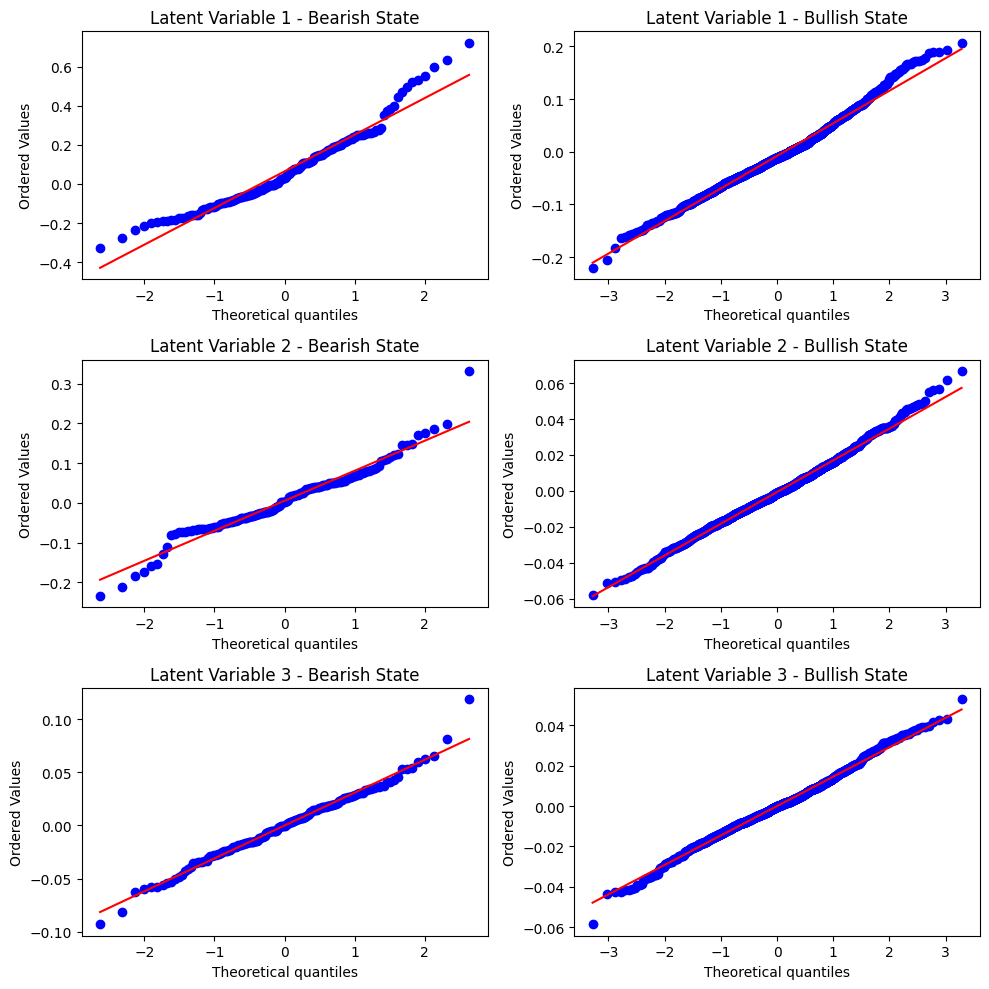

In [22]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10,10))
for i in range(X_bear.shape[1]):
    
    stats.probplot(X_bear[:, i], dist='norm', plot=axes[i,0])
    axes[i,0].set_title(f'Latent Variable {i+1} - Bearish State')
    
    stats.probplot(X_bull[:, i], dist='norm', plot=axes[i,1])
    axes[i,1].set_title(f'Latent Variable {i+1} - Bullish State')

plt.tight_layout()
plt.show()

Result show mostly agreement between the theoretical quantiles and ordered values which indicates that the Gaussian model was a proper choice for this data. The slight skew in the top left can be explained by heavy tails in the distribution which is expected in the bearish state as there are far fewer data points (outliers get amplified).

## Analysis on the Log-Likelihood of the 

This score is the probability of seeing the data given the model and its parameters. Positive values are fine since we are using a continuous Guassian model for the emission probabilities, meaning they are probability density functions not discrete probabilities and can therefore take valeus greater than 1. 

Have to normalize to the length of data since the loglikelihood is just a sum of loglikelihood over the entire sequence so naturally longer sequences will have a greater score. 

In [14]:
train_score = np.round(hmm_model.score(latent_train), decimals=3)
print(f'Log-Likelihood of Training Data: {train_score}')

Log-Likelihood of Training Data: 9427.631


In [23]:
print(f'Normalized Log-Lieklihood of Training Data: {np.round(train_score/len(train_data), decimals=4)}')

NameError: name 'train_score' is not defined

In [16]:
test_score = np.round(hmm_model.score(latent_test), decimals=3)

print(f"Log-Lkelihood of the Test Data: {test_score}")

Log-Lkelihood of the Test Data: 2048.232


In [ ]:
print(f'Normalized Log-Likelihood of Testing Data: {np.round(train_score/len(train_data), decimals=4)}')

np.float64(6.628582524271844)

As we can see the training and testing normalized log likelihoods are roughly equivalent. This is a sign that the model is not overfit to the training data and that the model's parameters are actually quite good for the time series data. 

A slight increase in the testing log likelihood could be explained by less extreme values in the testing set as opposed to the training set. As outliers are harder to model this would lead to low log-likelihoods for these observations. 

We can quickly see that in the standard deviation of the training set is much greater (~5x) that of the testing set for the PC1 latent variables. Given PC1 latent variabels have the greatest state mean contribution for each state more volatility in this component would elad to worse log-likelihoods. 

For this specific data set a prime example owuld be the fact that 2020 financial crisis appears in the training set but ntohing comparable occurs in the testing set. This data ould be very hard to model thus resulting in low log-likelihood for those observaiton whihc would bring down the average LLH in the training set.

In [29]:
np.round(np.std(latent_train[0]),decimals=5), np.round(np.std(latent_test[0]), decimals=5)

(np.float64(0.05877), np.float64(0.01171))

### Plotting of the predicted states for the training and testing data

In [19]:
probs_test = pd.Series(hmm_model.predict(latent_test), index = test_data.index)

probs_train = pd.Series(hmm_model.predict(latent_train), index = train_data.index)

Text(0, 0.5, 'Daily % Returns')

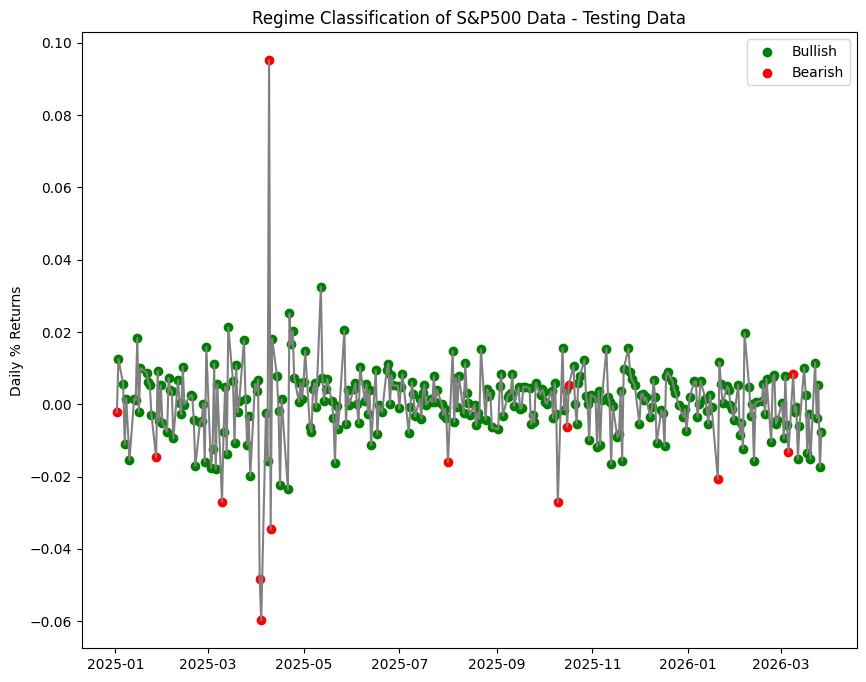

In [20]:
plt.figure(figsize=(10,8))
plt.plot(test_data['^SPX'], color='gray')
plt.scatter(test_data.index[probs_test == 1], test_data['^SPX'][probs_test == 1], color='green', label = 'Bullish')
plt.scatter(test_data.index[probs_test == 0], test_data['^SPX'][probs_test == 0], color='red', label = 'Bearish')
plt.title("Regime Classification of S&P500 Data - Testing Data")
plt.legend()
plt.ylabel("Daily % Returns")

Text(0, 0.5, 'Daily % Returns')

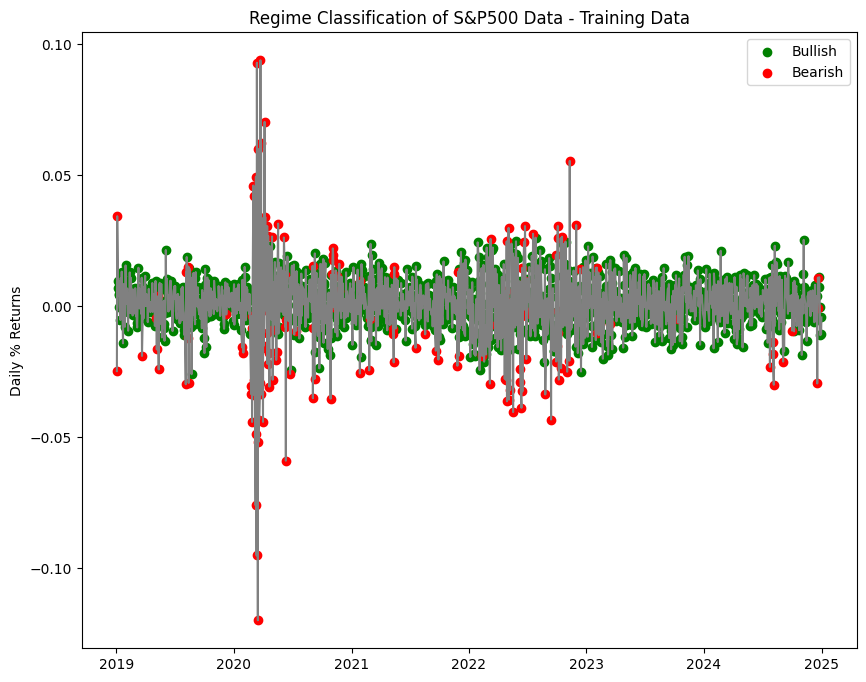

In [21]:
plt.figure(figsize=(10,8))
plt.plot(train_data['^SPX'], color='gray')
plt.scatter(train_data.index[probs_train == 1], train_data['^SPX'][probs_train  == 1], color='green', label = 'Bullish')
plt.scatter(train_data.index[probs_train  == 0], train_data['^SPX'][probs_train  == 0], color='red', label = 'Bearish')
plt.title("Regime Classification of S&P500 Data - Training Data")
plt.legend()
plt.ylabel("Daily % Returns")